# Sprawozdanie z projektu:
# Przestrzenie ciagle - Blackjack4game-v1 (betting)

Jakub Labuz\
Maciej Maj

24 maja 2026

### 1. Wstep i cel projektu

Celem jest przetestowanie srodowiska ciaglego Blackjack4game-v1 (akcja zawiera stawke oraz decyzje w grze) oraz przygotowanie raportu z wynikow uczenia agenta w przestrzeni ciaglej. Raport obejmuje opis srodowiska, algorytmu, doboru hiperparametrow, krzywe uczenia, porownanie architektur sieci oraz ewaluacje najlepszego agenta w trybie bez eksploracji.

### 2. Charakterystyka srodowiska ciaglego (Blackjack4game-v1)

Blackjack4game-v1 to klasyczny Blackjack rozszerzony o faze stawki: akcja jest wektorem ciaglym [bet, decision], gdzie bet jest w [0, 1], a decision jest liczba rzeczywista mapowana na decyzje dyskretne 0-4; obserwacja to slownik z player_points, not_used_ace, dealer_card oraz opcjonalnie running_count, a poprawne decyzje sa ograniczane maska z info["action_mask"]; nagroda w fazie gry jest wynikiem rozdania pomnozonym przez stawke, a w fazie stawki wynosi 0.

### 3. Charakterystyka wybranego algorytmu

Zastosowano Actor-Critic z jednym wspolnym trzonem i trzema glowicami: bet (srednia rozkladu normalnego po sigmoidzie, z uczonym log_std), decision (logity dla 5 akcji z maska), value (wartosc stanu); w treningu akcje sa probkowane, a aktualizacja opiera sie o advantage (returns - value), natomiast w ewaluacji stosowana jest decyzja deterministyczna (argmax i srednia stawka).

### 4. Konfiguracja srodowiska i zaleznosci

In [109]:
# If torch is missing, uncomment the line below and run this cell.
# %pip install torch --index-url https://download.pytorch.org/whl/cpu

In [110]:
import time
import random
import numpy as np
import gymnasium as gym
import blackjack_env
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [111]:
NUM_RUNS = 10
TOTAL_STEPS = 50000
MAX_STEPS = 200
BLOCK_STEPS = 1000
EVAL_EPISODES = 50

In [112]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def obs_to_vector(obs: dict, has_running_count: bool) -> np.ndarray:
    if has_running_count:
        return np.array(
            [
                obs["player_points"] / 21.0,
                obs["not_used_ace"] / 3.0,
                (obs["dealer_card"] - 1) / 10.0,
                (obs["running_count"] + 20) / 40.0,
            ],
            dtype=np.float32,
        )
    return np.array(
        [
            obs["player_points"] / 21.0,
            obs["not_used_ace"] / 3.0,
            (obs["dealer_card"] - 1) / 10.0,
        ],
        dtype=np.float32,
    )


class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, hidden_sizes: tuple[int, ...], n_actions: int = 5):
        super().__init__()
        layers: list[nn.Module] = []
        in_dim = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        self.shared = nn.Sequential(*layers)
        self.bet_head = nn.Linear(in_dim, 1)
        self.dec_head = nn.Linear(in_dim, n_actions)
        self.value_head = nn.Linear(in_dim, 1)
        self.log_std = nn.Parameter(torch.tensor(0.2))

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.shared(x)
        bet_mean = torch.sigmoid(self.bet_head(h))
        logits = self.dec_head(h)
        value = self.value_head(h).squeeze(-1)
        return bet_mean, logits, value

    def act(
        self,
        obs_vec: np.ndarray,
        action_mask: np.ndarray | None,
        deterministic: bool = False,
    ) -> tuple[np.ndarray, torch.Tensor, torch.Tensor, torch.Tensor]:
        x = torch.tensor(obs_vec, dtype=torch.float32, device=self.log_std.device)
        bet_mean, logits, value = self.forward(x)
        bet_std = torch.exp(self.log_std)
        bet_dist = torch.distributions.Normal(bet_mean, bet_std)
        if deterministic:
            bet = bet_mean
        else:
            bet = bet_dist.rsample()
        bet = torch.clamp(bet, 0.0, 1.0)
        if action_mask is not None:
            mask = torch.tensor(action_mask, dtype=torch.bool, device=logits.device)
            logits = logits.masked_fill(~mask, -1e9)
        dec_dist = torch.distributions.Categorical(logits=logits)
        if deterministic:
            decision = torch.argmax(logits, dim=-1)
        else:
            decision = dec_dist.sample()
        log_prob = bet_dist.log_prob(bet).sum(-1) + dec_dist.log_prob(decision)
        entropy = bet_dist.entropy().sum(-1) + dec_dist.entropy()
        action = np.array([bet.item(), float(decision.item())], dtype=np.float32)
        return action, log_prob, entropy, value

### 4. Definicja i wybor hiperparametrow

Testowano trzy zestawy hiperparametrow (architektura A), a trening oparto o liczbe krokow (TOTAL_STEPS=50000) z blokami po BLOCK_STEPS=1000 oraz NUM_RUNS=10 powtorzeniami; krzywe uczenia ponizej prezentuja srednia nagrode w blokach krokow.

* **HP1:** lr=3e-4, gamma=0.99, entropy_coef=0.02, value_coef=0.5, bet_threshold=0.1, bet_penalty_coef=0.1
* **HP2:** lr=1e-4, gamma=0.98, entropy_coef=0.01, value_coef=0.5, bet_threshold=0.1, bet_penalty_coef=0.1
* **HP3:** lr=5e-4, gamma=0.99, entropy_coef=0.02, value_coef=0.7, bet_threshold=0.1, bet_penalty_coef=0.1

In [113]:
def train_agent(
    env: gym.Env,
    model: ActorCritic,
    config: dict,
    total_steps: int = 50000,
    max_steps: int = 200,
    block_steps: int = 1000,
    progress_every_steps: int | None = None,
    run_label: str | None = None,
    **kwargs,
) -> dict:
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    gamma = config["gamma"]
    entropy_coef = config["entropy_coef"]
    value_coef = config["value_coef"]
    block_rewards: list[float] = []
    losses: list[float] = []
    steps_total = 0
    has_running_count = "running_count" in env.observation_space.spaces
    bet_threshold = float(config.get("bet_threshold", 0.1))
    bet_penalty_coef = float(config.get("bet_penalty_coef", 0.1))
    if progress_every_steps is None:
        progress_every_steps = max(1, total_steps // 10)
    block_steps = max(1, block_steps)
    current_block_rewards: list[float] = []
    episodes_completed = 0

    while steps_total < total_steps:
        obs, info = env.reset()
        ep_rewards = 0.0
        log_probs = []
        values = []
        rewards = []
        entropies = []

        for _ in range(max_steps):
            obs_vec = obs_to_vector(obs, has_running_count)
            action_mask = info.get("action_mask", None) if isinstance(info, dict) else None
            action, log_prob, entropy, value = model.act(obs_vec, action_mask)
            next_obs, reward, done, truncated, info = env.step(action)
            bet = float(action[0])
            if bet < bet_threshold:
                reward -= bet_penalty_coef * (bet_threshold - bet)
            steps_total += 1

            log_probs.append(log_prob)
            values.append(value)
            rewards.append(reward)
            entropies.append(entropy)
            ep_rewards += reward
            obs = next_obs
            if progress_every_steps and steps_total % progress_every_steps == 0:
                if run_label:
                    msg = f"{run_label} steps {steps_total}/{total_steps}"
                else:
                    msg = f"Progress: step {steps_total}/{total_steps}"
                if episodes_completed > 0:
                    msg += f" | ep {episodes_completed}"
                print(msg)
            if done or truncated or steps_total >= total_steps:
                break

        returns = []
        G = 0.0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()
        returns_t = torch.tensor(returns, dtype=torch.float32, device=model.log_std.device)
        values_t = torch.stack(values)
        log_probs_t = torch.stack(log_probs)
        entropies_t = torch.stack(entropies)
        advantages = returns_t - values_t.detach()
        policy_loss = -(log_probs_t * advantages).mean()
        value_loss = value_coef * (returns_t - values_t).pow(2).mean()
        entropy_loss = -entropy_coef * entropies_t.mean()
        loss = policy_loss + value_loss + entropy_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        current_block_rewards.append(ep_rewards)
        episodes_completed += 1

        if steps_total % block_steps == 0:
            block_rewards.append(float(np.mean(current_block_rewards)))
            current_block_rewards = []

    if current_block_rewards:
        block_rewards.append(float(np.mean(current_block_rewards)))

    return {"block_rewards": block_rewards, "losses": losses}

In [114]:
def evaluate_agent(
    model: ActorCritic,
    env_id: str,
    episodes: int = 50,
    intelligence_mode: bool = False,
    max_steps: int = 200,
    seed: int | None = None,
    deterministic: bool = True,
    ) -> tuple[float, float]:
    if seed is not None:
        set_seed(seed)
    env = gym.make(env_id, render_mode=None, intelligence_mode=intelligence_mode)
    has_running_count = "running_count" in env.observation_space.spaces
    rewards = []
    for _ in range(episodes):
        obs, info = env.reset()
        ep_reward = 0.0
        for _ in range(max_steps):
            obs_vec = obs_to_vector(obs, has_running_count)
            action_mask = info.get("action_mask", None) if isinstance(info, dict) else None
            action, _, _, _ = model.act(obs_vec, action_mask, deterministic=deterministic)
            obs, reward, done, truncated, info = env.step(action)
            ep_reward += reward
            if done or truncated:
                break
        rewards.append(ep_reward)
    env.close()
    return float(np.mean(rewards)), float(np.std(rewards))

In [115]:
HYPERPARAM_SETS = {
    "HP1": {"lr": 3e-4, "gamma": 0.99, "entropy_coef": 0.02, "value_coef": 0.5, "bet_penalty_coef": 0.1, "bet_threshold": 0.1},
    "HP2": {"lr": 1e-4, "gamma": 0.98, "entropy_coef": 0.01, "value_coef": 0.5, "bet_penalty_coef": 0.1, "bet_threshold": 0.1},
    "HP3": {"lr": 5e-4, "gamma": 0.99, "entropy_coef": 0.02, "value_coef": 0.7, "bet_penalty_coef": 0.1, "bet_threshold": 0.1},
}

In [116]:
ENV_ID = "Blackjack4game-v1"
HIDDEN_SIZES = (128, 128)

print(f"Parametry treningu: TOTAL_STEPS={TOTAL_STEPS}, NUM_RUNS={NUM_RUNS}")


def make_env(intelligence_mode: bool = False) -> gym.Env:
    return gym.make(ENV_ID, render_mode=None, intelligence_mode=intelligence_mode)


def make_model(env: gym.Env, hidden_sizes: tuple[int, ...]) -> ActorCritic:
    has_running_count = "running_count" in env.observation_space.spaces
    obs_dim = 4 if has_running_count else 3
    model = ActorCritic(obs_dim, hidden_sizes)
    return model.to(DEVICE)


def aggregate_runs(runs: list[list[float]]) -> tuple[np.ndarray, np.ndarray]:
    max_len = max(len(r) for r in runs)
    data = np.full((len(runs), max_len), np.nan, dtype=np.float32)
    for i, r in enumerate(runs):
        data[i, : len(r)] = r
    return np.nanmean(data, axis=0), np.nanstd(data, axis=0)


results_hp: dict[str, list[list[float]]] = {}
timings_hp: dict[str, list[float]] = {}


for name, cfg in HYPERPARAM_SETS.items():
    runs: list[list[float]] = []
    step_times: list[float] = []
    for run_idx in range(NUM_RUNS):
        run_label = f"{name} run {run_idx + 1}/{NUM_RUNS}"
        print(run_label)
        set_seed(1000 + run_idx)
        env = make_env(intelligence_mode=False)
        model = make_model(env, HIDDEN_SIZES)
        start = time.perf_counter()
        out = train_agent(
            env,
            model,
            cfg,
            total_steps=TOTAL_STEPS,
            max_steps=MAX_STEPS,
            block_steps=BLOCK_STEPS,
            progress_every_steps=None,
            run_label=run_label,
        )
        elapsed = time.perf_counter() - start
        env.close()
        rewards = out["block_rewards"]
        runs.append(rewards)
        step_times.append(elapsed / max(1, TOTAL_STEPS))
    results_hp[name] = runs
    timings_hp[name] = step_times

Parametry treningu: TOTAL_STEPS=50000, NUM_RUNS=10
HP1 run 1/10
HP1 run 1/10 steps 5000/50000 | ep 4249
HP1 run 1/10 steps 10000/50000 | ep 8707
HP1 run 1/10 steps 15000/50000 | ep 12947
HP1 run 1/10 steps 20000/50000 | ep 16674
HP1 run 1/10 steps 25000/50000 | ep 19833
HP1 run 1/10 steps 30000/50000 | ep 22671
HP1 run 1/10 steps 35000/50000 | ep 25674
HP1 run 1/10 steps 40000/50000 | ep 28497
HP1 run 1/10 steps 45000/50000 | ep 31418
HP1 run 1/10 steps 50000/50000 | ep 34171
HP1 run 2/10
HP1 run 2/10 steps 5000/50000 | ep 4444
HP1 run 2/10 steps 10000/50000 | ep 8930
HP1 run 2/10 steps 15000/50000 | ep 13029
HP1 run 2/10 steps 20000/50000 | ep 16554
HP1 run 2/10 steps 25000/50000 | ep 19789
HP1 run 2/10 steps 30000/50000 | ep 23006
HP1 run 2/10 steps 35000/50000 | ep 25992
HP1 run 2/10 steps 40000/50000 | ep 28995
HP1 run 2/10 steps 45000/50000 | ep 32120
HP1 run 2/10 steps 50000/50000 | ep 35083
HP1 run 3/10
HP1 run 3/10 steps 5000/50000 | ep 4527
HP1 run 3/10 steps 10000/50000 | ep 

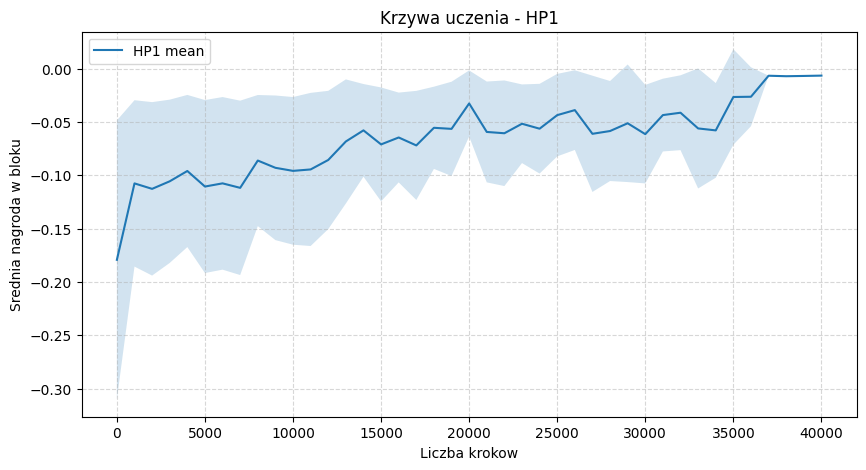

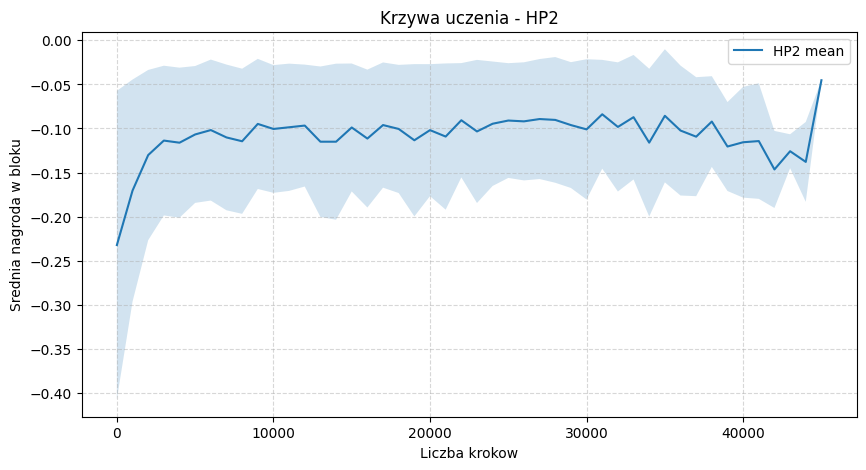

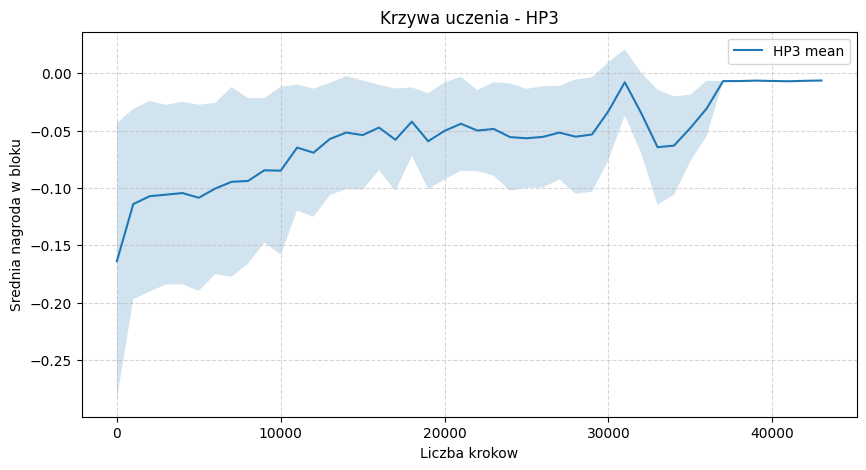

In [117]:
for name, runs in results_hp.items():
    mean, std = aggregate_runs(runs)
    x = np.arange(len(mean)) * BLOCK_STEPS
    plt.figure(figsize=(10, 5))
    plt.plot(x, mean, label=f"{name} mean")
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)
    plt.title(f"Krzywa uczenia - {name}")
    plt.xlabel("Liczba krokow")
    plt.ylabel("Srednia nagroda w bloku")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

### 7. Czas kroku srodowiska

Ponizszy blok podaje sredni czas jednego kroku czasowego (elapsed / TOTAL_STEPS) z uruchomien treningowych, wraz z odchyleniem standardowym. Jesli potrzebny jest czas jednego epizodu, mozna go oszacowac przez pomnozenie tego wyniku przez srednia dlugosc epizodu.

In [118]:
for name, step_times in timings_hp.items():
    print(f"{name}: mean {np.mean(step_times):.6f}s, std {np.std(step_times):.6f}s")

HP1: mean 0.002435s, std 0.000077s
HP2: mean 0.003493s, std 0.001135s
HP3: mean 0.002813s, std 0.000148s


### 8. Porownanie architektur sieci

Ponizej porownano dwie architektury oznaczone jako A i B. W tej wersji kodu obie korzystaja z tego samego rozmiaru trzonu (HIDDEN_SIZES=(128, 128)), wiec roznice wynikow odzwierciedlaja glownie losowosc uczenia.

**Wejscie:** wektor cech [player_points/21, not_used_ace/3, dealer_card/10, opcjonalnie running_count/40].

**Schemat (A i B):**
- Linear(wejscie -> 128) + ReLU
- Linear(128 -> 128) + ReLU
- Glowa bet: Linear(128 -> 1) + sigmoid (srednia stawki)
- Glowa decision: Linear(128 -> 5) (logity, z maska akcji)
- Glowa value: Linear(128 -> 1) (wartosc stanu)

**Wyjscie:** bet w [0, 1], decyzja dyskretna 0-4 (z logits), oraz wartosc stanu.

arch-A run 1/10 steps 5000/50000 | ep 4551
arch-A run 1/10 steps 10000/50000 | ep 9232
arch-A run 1/10 steps 15000/50000 | ep 13083
arch-A run 1/10 steps 20000/50000 | ep 16602
arch-A run 1/10 steps 25000/50000 | ep 19820
arch-A run 1/10 steps 30000/50000 | ep 22912
arch-A run 1/10 steps 35000/50000 | ep 25955
arch-A run 1/10 steps 40000/50000 | ep 28814
arch-A run 1/10 steps 45000/50000 | ep 31626
arch-A run 1/10 steps 50000/50000 | ep 34320
arch-A run 2/10 steps 5000/50000 | ep 3740
arch-A run 2/10 steps 10000/50000 | ep 7498
arch-A run 2/10 steps 15000/50000 | ep 11165
arch-A run 2/10 steps 20000/50000 | ep 14897
arch-A run 2/10 steps 25000/50000 | ep 18638
arch-A run 2/10 steps 30000/50000 | ep 22331
arch-A run 2/10 steps 35000/50000 | ep 25992
arch-A run 2/10 steps 40000/50000 | ep 29717
arch-A run 2/10 steps 45000/50000 | ep 33428
arch-A run 2/10 steps 50000/50000 | ep 37185
arch-A run 3/10 steps 5000/50000 | ep 4363
arch-A run 3/10 steps 10000/50000 | ep 8735
arch-A run 3/10 ste

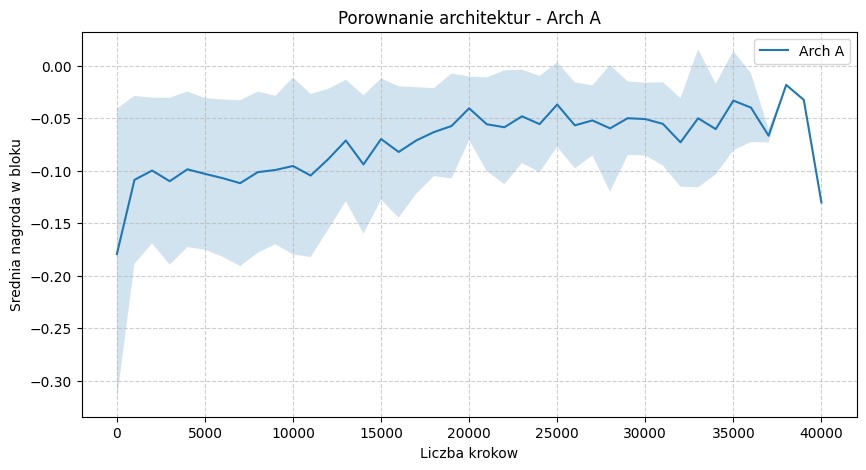

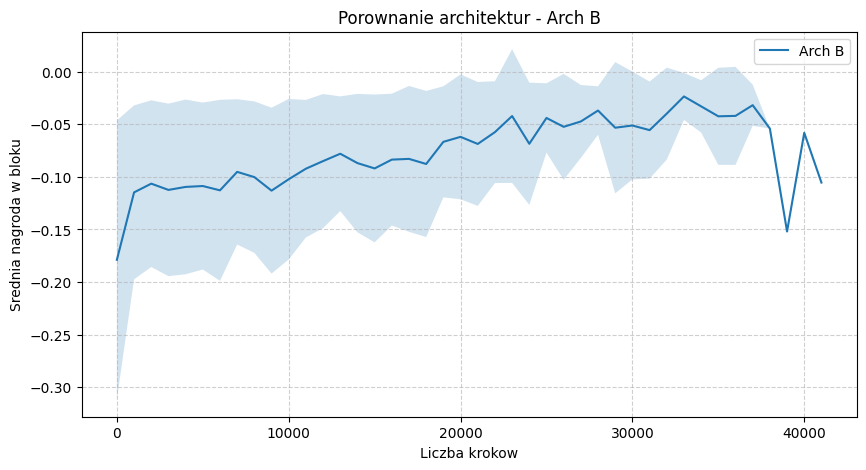

In [119]:
ARCH_CONFIG = HYPERPARAM_SETS["HP1"]
results_arch = {}

for arch in ["A", "B"]:
    runs = []
    for run_idx in range(NUM_RUNS):
        run_label = f"arch-{arch} run {run_idx + 1}/{NUM_RUNS}"
        set_seed(2000 + run_idx)
        env = make_env(intelligence_mode=False)
        model = make_model(env, HIDDEN_SIZES)
        out = train_agent(
            env,
            model,
            ARCH_CONFIG,
            total_steps=TOTAL_STEPS,
            max_steps=MAX_STEPS,
            block_steps=BLOCK_STEPS,
            progress_every_steps=None,
            run_label=run_label,
        )
        env.close()
        runs.append(out["block_rewards"])
    results_arch[arch] = runs

for arch, runs in results_arch.items():
    mean, std = aggregate_runs(runs)
    x = np.arange(len(mean)) * BLOCK_STEPS
    plt.figure(figsize=(10, 5))
    plt.plot(x, mean, label=f"Arch {arch}")
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)
    plt.title(f"Porownanie architektur - Arch {arch}")
    plt.xlabel("Liczba krokow")
    plt.ylabel("Srednia nagroda w bloku")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

### 9. Najlepszy agent i symulacja bez eksploracji

Najlepszy zestaw wybierany jest na podstawie sredniej nagrody z ostatnich 5 blokow (score_runs), nastepnie agent jest trenowany ponownie i ewaluowany deterministycznie na 50 epizodach. Porownanie wykonuje sie przez zestawienie sredniej z ewaluacji (eval_mean) z srednia z konca krzywej uczenia (tail_mean); zgodnosc sugeruje stabilna polityke, a istotna roznica moze wskazywac niestabilnosc lub przecenienie wyniku w treningu.

In [120]:
import os


def score_runs(runs: list[list[float]], tail: int = 5) -> float:
    scores = []
    for r in runs:
        t = min(tail, len(r))
        if t == 0:
            continue
        scores.append(float(np.mean(r[-t:])))
    return float(np.mean(scores)) if scores else float("-inf")


scores = {name: score_runs(runs) for name, runs in results_hp.items()}
best_name = max(scores, key=scores.get)
print("Best config:", best_name, "score:", scores[best_name])

best_cfg = HYPERPARAM_SETS[best_name]
set_seed(999)
best_env = make_env(intelligence_mode=False)
best_model = make_model(best_env, HIDDEN_SIZES)
out = train_agent(
    best_env,
    best_model,
    best_cfg,
    total_steps=TOTAL_STEPS,
    max_steps=MAX_STEPS,
    block_steps=BLOCK_STEPS,
    progress_every_steps=None,
    run_label="best",
)
best_env.close()
best_rewards = out["block_rewards"]

os.makedirs("results/continuous", exist_ok=True)
torch.save(best_model.state_dict(), "results/continuous/best_model.pt")

eval_mean, eval_std = evaluate_agent(best_model, ENV_ID, episodes=EVAL_EPISODES, intelligence_mode=False)
tail_mean = float(np.mean(best_rewards[-5:])) if len(best_rewards) >= 5 else float(np.mean(best_rewards))
print(f"Eval (deterministic): mean={eval_mean:.3f}, std={eval_std:.3f}")
print(f"Training tail mean: {tail_mean:.3f}")

Best config: HP3 score: -0.04806231436081217
best steps 5000/50000 | ep 4501
best steps 10000/50000 | ep 8464
best steps 15000/50000 | ep 11706
best steps 20000/50000 | ep 14728
best steps 25000/50000 | ep 17487
best steps 30000/50000 | ep 20161
best steps 35000/50000 | ep 22975
best steps 40000/50000 | ep 25906
best steps 45000/50000 | ep 28901
best steps 50000/50000 | ep 31547
Eval (deterministic): mean=-2.000, std=13.093
Training tail mean: -0.063


### 10. Wnioski

- Najlepszy zestaw hiperparametrow to ten wskazany przez score_runs; o wyraznej przewadze mozna mowic, gdy jego krzywa uczenia jest stale wyzej i ma mniejsze odchylenie standardowe.
- Jesli krzywe sie przecinaja i roznice sa niewielkie, brak jednoznacznego lidera; w takim przypadku o wyborze decyduje stabilnosc (mniejsze wahania) oraz zgodnosc wyniku ewaluacji z koncem krzywej uczenia.
- Krzywe uczenia oraz pomiar czasu kroku pozwalaja ocenic kompromis miedzy jakoscia a kosztem treningu.